<a href="https://colab.research.google.com/github/chihway/mapping_the_universe/blob/main/Basic/Tutorial%202%20-%20Galaxy%20Catalogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial 2 - Galaxy Catalogs

In this tutorial we will learn how to manipulate a galaxy catalog and make some simple plots. In this tutorial you will be able to

* read and understand what a fits table is
* read and understand what a hdf5 table is
* plot columns of the galaxy catalog
* manipulate the catalog and add new columns 
* use pandas to do some of these operations

If you already know all of this, feel free to skip to [Tutorial 3 - Galaxy Images](https://github.com/chihway/mapping_the_universe/blob/main/Basic/Tutorial%203%20-%20Galaxy%20Images.ipynb).


Here are some new python packages that are introduced in this tutorial:

* `astropy` (https://www.astropy.org/): open-source Python library designed for astrophysics research. It provides tools for performing a wide range of astronomical computations and data processing tasks. Astropy is built on top of the popular scientific Python stack (NumPy, SciPy, and matplotlib).

* `h5py` (https://www.h5py.org/): Python library that provides a simple and efficient interface to the HDF5 (Hierarchical Data Format) file format. HDF5 is a popular format for storing large amounts of numerical data, often used in scientific computing, machine learning, and data analysis.  

* `pandas` (https://pandas.pydata.org/): open-source Python library designed for data manipulation, analysis, and exploration. It provides powerful and flexible tools for working with structured data, such as tabular data in spreadsheets or databases, and is widely used in data science, machine learning, and general programming.

In [1]:
import astropy
import astropy.io.fits as pf
import numpy as np
import scipy
import matplotlib.pyplot as plt
import h5py
import pandas as pd

In [2]:
# we need to first download some files -- these are the DES Y3 deep field catalogs
# you can read about the catalog here: https://arxiv.org/abs/2012.12824
# the schema of the catalog can be found here: https://des.ncsa.illinois.edu/releases/y3a2/Y3deepfields

# once you executed this once, you can comment out these two lines
!curl -O https://portal.nersc.gov/cfs/lsst/chihway/mapping_the_universe/des_y3_deepfield.fits.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  333M  100  333M    0     0  12.2M      0  0:00:27  0:00:27 --:--:-- 12.0M0:00:25  0:00:09  0:00:16 13.0M26  0:00:17  0:00:09 11.1M:00:27  0:00:22  0:00:05 11.6M


In [3]:
# you'll need to install this package to turn the fits file to an hdf5 file
# git clone https://github.com/telegraphic/fits2hdf
# cd fits2hdf
# python setup.py install

from fits2hdf.io.fitsio import read_fits
from fits2hdf.io.hdfio import export_hdf
a = read_fits('des_y3_deepfield.fits.gz')
export_hdf(a, 'des_y3_deepfield.hdf5')

## Reading and manipulating a FITS file

For the full information, please see https://docs.astropy.org/en/stable/io/fits/index.html

In [4]:
# read the file

fitsfile = pf.open('des_y3_deepfield.fits.gz')

In [5]:
# shows how many extensions the file has, for typical catalogs, the first extension (index 0)
# is usually empty, and the catalog content starts from the second (index 1) extension
# we also see that the catalog has 2826988 rows/objects, each with 22 columns/properties

fitsfile.info()

Filename: des_y3_deepfield.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   ()      
  1                1 BinTableHDU     65   2826988R x 24C   [K, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, K, K, K, K]   


In [6]:
# you can see what the catalog contains from the header

fitsfile[1].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / 8-bit bytes                                    
NAXIS   =                    2 / 2-dimensional binary table                     
NAXIS1  =                  192 / width of table in bytes                        
NAXIS2  =              2826988 / number of rows in table                        
PCOUNT  =                    0 / size of special data area                      
GCOUNT  =                    1 / one data group (required keyword)              
TFIELDS =                   24 / number of fields in each row                   
TTYPE1  = 'ID      '           / label for field   1                            
TFORM1  = 'K       '           / data format of field: 8-byte INTEGER           
TTYPE2  = 'RA      '           / label for field   2                            
TFORM2  = 'D       '           / data format of field: 8-byte DOUBLE            
TTYPE3  = 'DEC     '        

In [7]:
# to access the data

fitsdata = fitsfile[1].data

In [8]:
# apply some basic masks to remove non-galaxy and other bad objects

mask = (fitsdata['KNN_CLASS']==1)*(fitsdata['FLAGS']==0)*(fitsdata['FLAGS_NIR']==0) \
                    *(fitsdata['MASK_FLAGS']==0)*(fitsdata['MASK_FLAGS_NIR']==0)

print('Number of objects after cuts:', len(fitsdata['RA'][mask]))

Number of objects after cuts: 1431620


Text(0.5, 0, 'Dec')

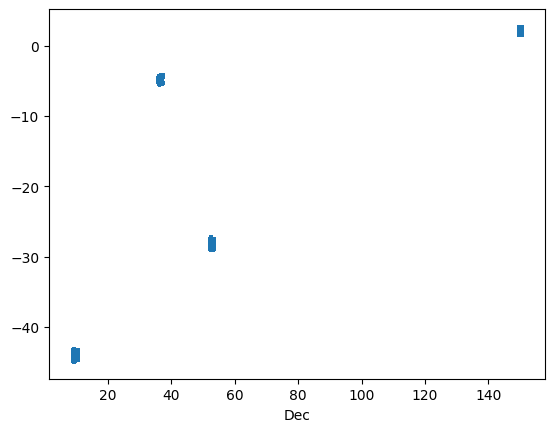

In [9]:
# plot the RA/DEC of the remaining objects to see where they are
# these are the 4 areas that cover the 10 deep fields: CDFS (SN-C1, SN-C2, SN-C3), 
# Elais-South (SN-E1, SN-E2), Stripe 82 (SN-S1, SN-S2) and XMM-LSS (SN-X1, SN-X2, SN-X3)

plt.scatter(fitsdata['RA'][mask], fitsdata['DEC'][mask], s=1)
plt.xlabel('RA')
plt.xlabel('Dec')

Text(0.5, 0, 'Dec')

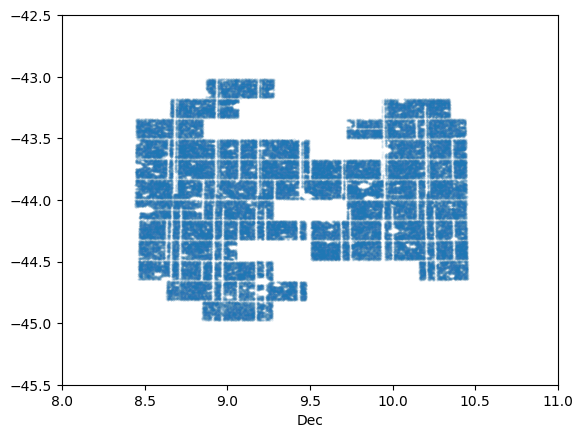

In [10]:
# zooming into one of the fields: Elais-South

plt.scatter(fitsdata['RA'][mask], fitsdata['DEC'][mask], s=0.1, alpha=0.1)
plt.xlim(8,11)
plt.ylim(-45.5,-42.5)
plt.xlabel('RA')
plt.xlabel('Dec')

/var/folders/mc/gj6kz6750g7dks2k81t8xyl80000gn/T/ipykernel_77879/3832239862.py:9: RuntimeWarning: invalid value encountered in log10
  return -2.5*np.log10(flux)+30.0


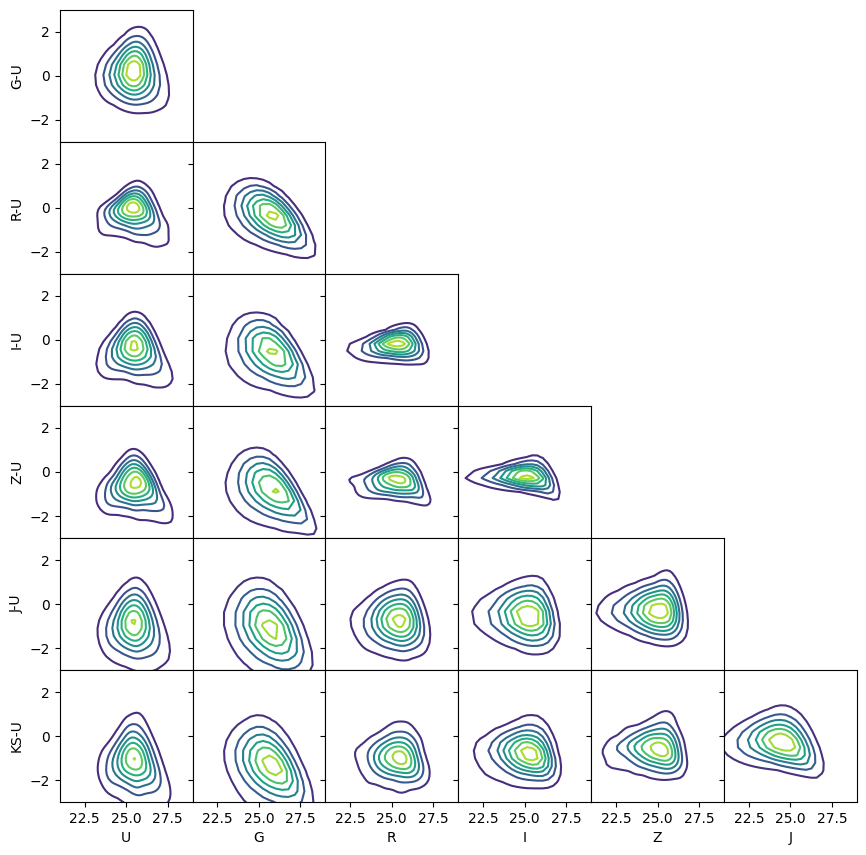

In [11]:
# make a color-magnitude plot

fitsdata_mask = fitsdata[mask][:10000]

from scipy.stats import gaussian_kde
from matplotlib.gridspec import GridSpec

def flux2mag(flux):
    return -2.5*np.log10(flux)+30.0

mag_u = flux2mag(fitsdata_mask['BDF_FLUX_DERED_CALIB_U'])
mag_g = flux2mag(fitsdata_mask['BDF_FLUX_DERED_CALIB_G'])
mag_r = flux2mag(fitsdata_mask['BDF_FLUX_DERED_CALIB_R'])
mag_i = flux2mag(fitsdata_mask['BDF_FLUX_DERED_CALIB_I'])
mag_z = flux2mag(fitsdata_mask['BDF_FLUX_DERED_CALIB_Z'])
mag_j = flux2mag(fitsdata_mask['BDF_FLUX_DERED_CALIB_J'])
mag_ks = flux2mag(fitsdata_mask['BDF_FLUX_DERED_CALIB_KS'])

mags = [mag_u,mag_g,mag_r,mag_i,mag_z,mag_j,mag_ks]
mags = np.nan_to_num(np.array(mags))
color = ['U','G','R','I','Z','J','KS']

fig = plt.figure(figsize=(12, 12))
gs = GridSpec(7, 7, hspace=0, wspace=0)

for i in range(7):
    for j in range(7):
        if i>j:
            
            # Calculate the point density using a kernel density estimation
            xy = np.vstack([mags[j], mags[i]-mags[j]])
            kde = gaussian_kde(xy)

            # Create a grid of points for the contour plot
            X, Y = np.mgrid[mags[j].min():mags[j].max():100j, (mags[i]-mags[j]).min():(mags[i]-mags[j]).max():100j]
            positions = np.vstack([X.ravel(), Y.ravel()])

            # Evaluate the KDE on the grid
            Z = np.reshape(kde(positions).T, X.shape)

            # Create the contour plot
            ax = fig.add_subplot(gs[i, j])
            ax.contour(X, Y, Z)
            if i==6:
                ax.set_xlabel(color[j])
            else:
                ax.set_xticklabels("")
            if j==0:
                ax.set_ylabel(color[i]+'-'+color[j])
            else:
                ax.set_yticklabels("")
                
            ax.set_xlim(21,29)
            ax.set_ylim(-3,3)


In [12]:
# add a new magnitude column

table_hdu = fitsfile[1]  # Assuming the table is in the second HDU (index 1)
data = table_hdu.data

# Create a new column
new_col = data.columns
for i in range(7):
    new_col += pf.Column(name='MAG_'+str(color[i]), format='D', array=flux2mag(fitsdata['BDF_FLUX_DERED_CALIB_'+str(color[i])]))

# Combine the new column with the existing columns
new_columns = pf.ColDefs(new_col)
updated_hdu = pf.BinTableHDU.from_columns(new_columns)

# Update the HDU
fitsfile[1] = updated_hdu

# update file
fitsfile.writeto('new.fits', overwrite=True)

/var/folders/mc/gj6kz6750g7dks2k81t8xyl80000gn/T/ipykernel_77879/3832239862.py:9: RuntimeWarning: invalid value encountered in log10
  return -2.5*np.log10(flux)+30.0


In [13]:
# check that the columns are indeed added
print(pf.open('new.fits')[1].header.keys)

# check that the new columns has reasonable values
print(pf.open('new.fits')[1].data['MAG_R'])

<bound method Header.keys of XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  248 / length of dimension 1                          
NAXIS2  =              2826988 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                   31 / number of table fields                         
TTYPE1  = 'ID      '                                                            
TFORM1  = 'K       '                                                            
TTYPE2  = 'RA      '                                                            
TFORM2  = 'D       '                                                            

## Reading in a hdf5 file and do the same thing

In [14]:
# check the structure of the h5 file
with h5py.File('des_y3_deepfield.hdf5','r') as f:
    print(f.keys())
    print(f['HDU0'].keys())
    print(f['HDU0/DATA'].keys())
    print(f['HDU0/DATA/RA'][:])

<KeysViewHDF5 ['HDU0', 'PRIMARY']>
<KeysViewHDF5 ['COMMENT', 'DATA', 'HISTORY']>
<KeysViewHDF5 ['BDF_FLUX_DERED_CALIB_G', 'BDF_FLUX_DERED_CALIB_H', 'BDF_FLUX_DERED_CALIB_I', 'BDF_FLUX_DERED_CALIB_J', 'BDF_FLUX_DERED_CALIB_KS', 'BDF_FLUX_DERED_CALIB_R', 'BDF_FLUX_DERED_CALIB_U', 'BDF_FLUX_DERED_CALIB_Z', 'BDF_FLUX_ERR_DERED_CALIB_G', 'BDF_FLUX_ERR_DERED_CALIB_H', 'BDF_FLUX_ERR_DERED_CALIB_I', 'BDF_FLUX_ERR_DERED_CALIB_J', 'BDF_FLUX_ERR_DERED_CALIB_KS', 'BDF_FLUX_ERR_DERED_CALIB_R', 'BDF_FLUX_ERR_DERED_CALIB_U', 'BDF_FLUX_ERR_DERED_CALIB_Z', 'DEC', 'FLAGS', 'FLAGS_NIR', 'ID', 'KNN_CLASS', 'MASK_FLAGS', 'MASK_FLAGS_NIR', 'RA']>
[ 52.22639313  52.43641176  52.18629346 ... 150.3735097  150.4827167
 150.30759158]


In [15]:
# extract data from file, note that columns of h5 files are sensitive to 
# capitalization of the names, while fits files are not

with h5py.File('des_y3_deepfield.hdf5','r') as f:
    knn_class = f['HDU0/DATA/KNN_CLASS'][:]
    flags = f['HDU0/DATA/FLAGS'][:]
    flags_nir = f['HDU0/DATA/FLAGS_NIR'][:]
    mask_flags = f['HDU0/DATA/MASK_FLAGS'][:]
    mask_flags_nir = f['HDU0/DATA/MASK_FLAGS_NIR'][:]
    
mask = (knn_class==1)*(flags==0)*(flags_nir==0)*(mask_flags==0)*(mask_flags_nir==0)

print('Number of objects after cuts:', len(flags[mask]))

Number of objects after cuts: 1431620


In [16]:
# add a column to the file
with h5py.File('des_y3_deepfield.hdf5', 'a') as f:
    for i in range(7):
        flux = f['HDU0/DATA/BDF_FLUX_DERED_CALIB_'+str(color[i])][:]
        f.create_dataset('HDU0/DATA/MAG_'+str(color[i]), data = flux2mag(flux))
    

/var/folders/mc/gj6kz6750g7dks2k81t8xyl80000gn/T/ipykernel_77879/3832239862.py:9: RuntimeWarning: invalid value encountered in log10
  return -2.5*np.log10(flux)+30.0


In [17]:
with h5py.File('des_y3_deepfield.hdf5','r') as f:
    print(f['HDU0/DATA'].keys())
    print(f['HDU0/DATA/MAG_R'][:])
    
# compare with previous fits file

<KeysViewHDF5 ['BDF_FLUX_DERED_CALIB_G', 'BDF_FLUX_DERED_CALIB_H', 'BDF_FLUX_DERED_CALIB_I', 'BDF_FLUX_DERED_CALIB_J', 'BDF_FLUX_DERED_CALIB_KS', 'BDF_FLUX_DERED_CALIB_R', 'BDF_FLUX_DERED_CALIB_U', 'BDF_FLUX_DERED_CALIB_Z', 'BDF_FLUX_ERR_DERED_CALIB_G', 'BDF_FLUX_ERR_DERED_CALIB_H', 'BDF_FLUX_ERR_DERED_CALIB_I', 'BDF_FLUX_ERR_DERED_CALIB_J', 'BDF_FLUX_ERR_DERED_CALIB_KS', 'BDF_FLUX_ERR_DERED_CALIB_R', 'BDF_FLUX_ERR_DERED_CALIB_U', 'BDF_FLUX_ERR_DERED_CALIB_Z', 'DEC', 'FLAGS', 'FLAGS_NIR', 'ID', 'KNN_CLASS', 'MAG_G', 'MAG_I', 'MAG_J', 'MAG_KS', 'MAG_R', 'MAG_U', 'MAG_Z', 'MASK_FLAGS', 'MASK_FLAGS_NIR', 'RA']>
[25.27929692 20.3807764  25.51158352 ... 25.10880669 24.42573198
 23.98694938]


## Now convert the fits file to a pandas frame

In [18]:
from astropy.table import Table

# Read the FITS file as an astropy Table
table = Table.read('des_y3_deepfield.fits.gz')

# Convert the Table to a pandas DataFrame
df = table.to_pandas()

In [19]:
# This is how a DataFrame looks like
print(df)

                ID          RA        DEC  BDF_FLUX_DERED_CALIB_U  \
0        691667164   52.226393 -27.126466            3.893833e+01   
1        691667165   52.436412 -27.127414            1.212539e+03   
2        691667166   52.186293 -27.125570            4.987256e+01   
3        691667173   52.365947 -27.120709           -9.999000e+09   
4        691667174   52.362233 -27.123560            3.575651e+01   
...            ...         ...        ...                     ...   
2826983  713204627  150.291560   1.581410            2.186965e+01   
2826984  713204628  150.566595   1.581395            3.122646e+01   
2826985  713204674  150.373510   1.580844            4.885428e+01   
2826986  713204675  150.482717   1.580812            1.235695e+02   
2826987  713204676  150.307592   1.580822            8.704930e+01   

         BDF_FLUX_DERED_CALIB_G  BDF_FLUX_DERED_CALIB_R  \
0                  6.223160e+01            7.731811e+01   
1                  3.075823e+03            7.041893e+

In [20]:
# Call single columns, they are all attributes to the DataFrame
df.RA

0           52.226393
1           52.436412
2           52.186293
3           52.365947
4           52.362233
              ...    
2826983    150.291560
2826984    150.566595
2826985    150.373510
2826986    150.482717
2826987    150.307592
Name: RA, Length: 2826988, dtype: float64

In [23]:
# Simple ways to access the index, the column names, the start and end entries
print(df.index)
print(df.columns)
print(df.head()['RA'])
print(df.tail()['RA'])

RangeIndex(start=0, stop=2826988, step=1)
Index(['ID', 'RA', 'DEC', 'BDF_FLUX_DERED_CALIB_U', 'BDF_FLUX_DERED_CALIB_G',
       'BDF_FLUX_DERED_CALIB_R', 'BDF_FLUX_DERED_CALIB_I',
       'BDF_FLUX_DERED_CALIB_Z', 'BDF_FLUX_DERED_CALIB_J',
       'BDF_FLUX_DERED_CALIB_H', 'BDF_FLUX_DERED_CALIB_KS',
       'BDF_FLUX_ERR_DERED_CALIB_U', 'BDF_FLUX_ERR_DERED_CALIB_G',
       'BDF_FLUX_ERR_DERED_CALIB_R', 'BDF_FLUX_ERR_DERED_CALIB_I',
       'BDF_FLUX_ERR_DERED_CALIB_Z', 'BDF_FLUX_ERR_DERED_CALIB_J',
       'BDF_FLUX_ERR_DERED_CALIB_H', 'BDF_FLUX_ERR_DERED_CALIB_KS',
       'KNN_CLASS', 'FLAGS', 'FLAGS_NIR', 'MASK_FLAGS', 'MASK_FLAGS_NIR'],
      dtype='object')
0    52.226393
1    52.436412
2    52.186293
3    52.365947
4    52.362233
Name: RA, dtype: float64
2826983    150.291560
2826984    150.566595
2826985    150.373510
2826986    150.482717
2826987    150.307592
Name: RA, dtype: float64


In [24]:
# Convert DaraFrame to numpy array if you need to
df.to_numpy()

array([[ 6.91667164e+08,  5.22263931e+01, -2.71264659e+01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 6.91667165e+08,  5.24364118e+01, -2.71274142e+01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 6.91667166e+08,  5.21862935e+01, -2.71255699e+01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 7.13204674e+08,  1.50373510e+02,  1.58084399e+00, ...,
         2.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 7.13204675e+08,  1.50482717e+02,  1.58081196e+00, ...,
         2.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 7.13204676e+08,  1.50307592e+02,  1.58082199e+00, ...,
         2.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

In [26]:
# Sort according to a column
df.sort_values(by="BDF_FLUX_DERED_CALIB_U")

,ID,RA,DEC,BDF_FLUX_DERED_CALIB_U,BDF_FLUX_DERED_CALIB_G,BDF_FLUX_DERED_CALIB_R,BDF_FLUX_DERED_CALIB_I,BDF_FLUX_DERED_CALIB_Z,BDF_FLUX_DERED_CALIB_J,BDF_FLUX_DERED_CALIB_H,...,BDF_FLUX_ERR_DERED_CALIB_I,BDF_FLUX_ERR_DERED_CALIB_Z,BDF_FLUX_ERR_DERED_CALIB_J,BDF_FLUX_ERR_DERED_CALIB_H,BDF_FLUX_ERR_DERED_CALIB_KS,KNN_CLASS,FLAGS,FLAGS_NIR,MASK_FLAGS,MASK_FLAGS_NIR
2480320,712779705,150.158182,1.616802,-9.999000e+09,-9.999000e+09,-9.999000e+09,-9.999000e+09,-9.999000e+09,8.182107e+01,9.080105e+01,...,9.999000e+09,9.999000e+09,7.517629e+01,1.032056e+02,1.447715e+02,0.0,16,0,64,64
1691989,699692199,10.329454,-43.826310,-9.999000e+09,-9.999000e+09,-9.999000e+09,-9.999000e+09,-9.999000e+09,5.180457e+02,7.425229e+02,...,9.999000e+09,9.999000e+09,2.401319e+01,1.853334e+01,2.381679e+01,0.0,2,0,0,0
2698329,712956443,150.580789,1.412657,-9.999000e+09,-9.999000e+09,-9.999000e+09,-9.999000e+09,-9.999000e+09,-9.999000e+09,-9.999000e+09,...,9.999000e+09,9.999000e+09,9.999000e+09,9.999000e+09,9.999000e+09,0.0,64,2,0,0
335893,692285021,51.597403,-27.800016,-9.999000e+09,-9.999000e+09,-9.999000e+09,-9.999000e+09,-9.999000e+09,-9.999000e+09,-9.999000e+09,...,9.999000e+09,9.999000e+09,9.999000e+09,9.999000e+09,9.999000e+09,0.0,16,2,32,32
797863,697464811,36.010907,-4.225055,-9.999000e+09,-9.999000e+09,-9.999000e+09,-9.999000e+09,-9.999000e+09,1.797316e+02,2.342494e+02,...,9.999000e+09,9.999000e+09,1.089885e+01,1.621093e+01,2.476429e+01,0.0,16,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
870164,697541327,35.497541,-4.508960,4.644034e+06,3.164099e+06,3.484553e+06,3.649813e+06,5.201609e+06,-9.999000e+09,-9.999000e+09,...,6.761948e+04,1.052448e+05,9.999000e+09,9.999000e+09,9.999000e+09,0.0,0,2,32,32
663781,697272601,36.600707,-3.878777,5.854774e+06,4.383852e+06,4.797077e+06,4.885063e+06,9.233047e+06,-9.999000e+09,-9.999000e+09,...,1.274449e+05,2.423434e+05,9.999000e+09,9.999000e+09,9.999000e+09,0.0,0,2,96,96
1009722,697978609,36.279376,-4.748937,5.892150e+06,4.286325e+06,4.872170e+06,4.985679e+06,7.243247e+06,-9.999000e+09,-9.999000e+09,...,1.104446e+05,1.721057e+05,9.999000e+09,9.999000e+09,9.999000e+09,0.0,0,2,0,0
1020915,697976434,36.279294,-4.745199,7.882095e+06,5.832561e+06,6.590231e+06,6.602505e+06,1.005170e+07,-9.999000e+09,-9.999000e+09,...,1.642852e+05,2.632423e+05,9.999000e+09,9.999000e+09,9.999000e+09,0.0,0,2,0,0


In [27]:
# Specify location of entry
df.loc[1443910:1443920, ["RA", "DEC"]]

,RA,DEC
1443910,10.377982,-43.798493
1443911,10.621006,-43.792927
1443912,10.454670,-43.794686
1443913,10.382035,-43.793298
1443914,10.567006,-43.793903
1443915,10.655808,-43.793856
1443916,10.729238,-43.793763
1443917,10.694778,-43.793908
1443918,10.466850,-43.794405
1443919,10.607381,-43.794486


In [28]:
# Filter for certain columns
df[df["KNN_CLASS"].isin([1,2])]

,ID,RA,DEC,BDF_FLUX_DERED_CALIB_U,BDF_FLUX_DERED_CALIB_G,BDF_FLUX_DERED_CALIB_R,BDF_FLUX_DERED_CALIB_I,BDF_FLUX_DERED_CALIB_Z,BDF_FLUX_DERED_CALIB_J,BDF_FLUX_DERED_CALIB_H,...,BDF_FLUX_ERR_DERED_CALIB_I,BDF_FLUX_ERR_DERED_CALIB_Z,BDF_FLUX_ERR_DERED_CALIB_J,BDF_FLUX_ERR_DERED_CALIB_H,BDF_FLUX_ERR_DERED_CALIB_KS,KNN_CLASS,FLAGS,FLAGS_NIR,MASK_FLAGS,MASK_FLAGS_NIR
0,691667164,52.226393,-27.126466,38.938325,62.231599,77.318110,75.844232,60.824882,138.549841,38.621868,...,9.731861,16.023497,13.122683,17.016402,24.857121,1.0,0,0,0,0
1,691667165,52.436412,-27.127414,1212.539105,3075.822573,7041.893320,9837.494998,11804.799977,17411.458251,20283.068656,...,22.988571,36.115409,28.659105,39.235304,53.728741,1.0,0,0,0,0
2,691667166,52.186293,-27.125570,49.872560,34.169152,62.426156,88.388970,125.860096,152.243088,70.311024,...,11.182541,19.361971,21.874789,25.844113,47.431546,1.0,0,0,0,0
4,691667174,52.362233,-27.123560,35.756508,42.250782,76.437113,58.901252,34.915384,167.368226,196.712313,...,13.961242,22.535491,15.346193,21.332031,28.064098,1.0,0,0,0,0
6,691667167,52.280562,-27.128727,59.342509,10.694164,86.847977,102.014874,183.618527,335.525582,175.109881,...,18.666962,34.783037,331.484657,45.528961,637.950531,1.0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2826860,713202659,150.337812,1.601086,76.264114,189.524704,373.407280,477.120199,534.214233,957.504129,914.980700,...,30.096842,37.457191,251.778931,288.353377,380.653859,1.0,0,0,0,0
2826861,713202660,150.394432,1.601021,31.524092,32.506200,38.009987,31.719349,44.001098,156.430899,209.113010,...,7.199224,11.489509,48.026114,33.945863,27.169000,1.0,0,0,0,0
2826864,713202708,150.316924,1.600502,17.793187,24.034324,49.040097,40.038735,34.851954,44.801503,19.899973,...,7.360756,11.389273,48.406986,17.562395,30.447006,1.0,0,0,0,0
2826866,713202755,150.341731,1.599826,119.890398,132.222714,261.885558,426.994104,439.040038,508.386838,567.642680,...,10.936676,16.035672,48.564941,50.994731,72.941249,1.0,0,0,0,0


In [29]:
# Take the mean of each column
df.mean()

ID                             7.017572e+08
RA                             7.160163e+01
DEC                           -1.616785e+01
BDF_FLUX_DERED_CALIB_U        -2.634015e+08
BDF_FLUX_DERED_CALIB_G        -2.634009e+08
BDF_FLUX_DERED_CALIB_R        -2.634007e+08
BDF_FLUX_DERED_CALIB_I        -2.633997e+08
BDF_FLUX_DERED_CALIB_Z        -2.633979e+08
BDF_FLUX_DERED_CALIB_J        -3.505790e+09
BDF_FLUX_DERED_CALIB_H        -3.505790e+09
BDF_FLUX_DERED_CALIB_KS       -3.505790e+09
BDF_FLUX_ERR_DERED_CALIB_U     2.634029e+08
BDF_FLUX_ERR_DERED_CALIB_G     2.634149e+08
BDF_FLUX_ERR_DERED_CALIB_R     2.634040e+08
BDF_FLUX_ERR_DERED_CALIB_I     2.634156e+08
BDF_FLUX_ERR_DERED_CALIB_Z     2.634387e+08
BDF_FLUX_ERR_DERED_CALIB_J     3.505791e+09
BDF_FLUX_ERR_DERED_CALIB_H     3.505791e+09
BDF_FLUX_ERR_DERED_CALIB_KS    3.505791e+09
KNN_CLASS                      5.697877e-01
FLAGS                          3.939465e-01
FLAGS_NIR                      2.652521e+00
MASK_FLAGS                     1

In [30]:
# Do simple algebra directly in the DataFrame
df.agg(lambda x: np.mean(x) * 5.6)

ID                             3.929840e+09
RA                             4.009691e+02
DEC                           -9.053997e+01
BDF_FLUX_DERED_CALIB_U        -1.475049e+09
BDF_FLUX_DERED_CALIB_G        -1.475045e+09
BDF_FLUX_DERED_CALIB_R        -1.475044e+09
BDF_FLUX_DERED_CALIB_I        -1.475038e+09
BDF_FLUX_DERED_CALIB_Z        -1.475028e+09
BDF_FLUX_DERED_CALIB_J        -1.963242e+10
BDF_FLUX_DERED_CALIB_H        -1.963242e+10
BDF_FLUX_DERED_CALIB_KS       -1.963242e+10
BDF_FLUX_ERR_DERED_CALIB_U     1.475056e+09
BDF_FLUX_ERR_DERED_CALIB_G     1.475123e+09
BDF_FLUX_ERR_DERED_CALIB_R     1.475062e+09
BDF_FLUX_ERR_DERED_CALIB_I     1.475127e+09
BDF_FLUX_ERR_DERED_CALIB_Z     1.475256e+09
BDF_FLUX_ERR_DERED_CALIB_J     1.963243e+10
BDF_FLUX_ERR_DERED_CALIB_H     1.963243e+10
BDF_FLUX_ERR_DERED_CALIB_KS    1.963243e+10
KNN_CLASS                      3.190811e+00
FLAGS                          2.206100e+00
FLAGS_NIR                      1.485412e+01
MASK_FLAGS                     5

In [31]:
# Do simple algebra directly in the DataFrame
df.transform(lambda x: x * 101.2)

,ID,RA,DEC,BDF_FLUX_DERED_CALIB_U,BDF_FLUX_DERED_CALIB_G,BDF_FLUX_DERED_CALIB_R,BDF_FLUX_DERED_CALIB_I,BDF_FLUX_DERED_CALIB_Z,BDF_FLUX_DERED_CALIB_J,BDF_FLUX_DERED_CALIB_H,...,BDF_FLUX_ERR_DERED_CALIB_I,BDF_FLUX_ERR_DERED_CALIB_Z,BDF_FLUX_ERR_DERED_CALIB_J,BDF_FLUX_ERR_DERED_CALIB_H,BDF_FLUX_ERR_DERED_CALIB_KS,KNN_CLASS,FLAGS,FLAGS_NIR,MASK_FLAGS,MASK_FLAGS_NIR
0,6.999672e+10,5285.310985,-2745.198351,3.940559e+03,6.297838e+03,7.824593e+03,7.675436e+03,6.155478e+03,1.402124e+04,3.908533e+03,...,9.848644e+02,1.621578e+03,1.328015e+03,1.722060e+03,2.515541e+03,101.2,0.0,0.0,0.0,0.0
1,6.999672e+10,5306.564870,-2745.294319,1.227090e+05,3.112732e+05,7.126396e+05,9.955545e+05,1.194646e+06,1.762040e+06,2.052647e+06,...,2.326443e+03,3.654879e+03,2.900301e+03,3.970613e+03,5.437349e+03,101.2,0.0,0.0,0.0,0.0
2,6.999672e+10,5281.252898,-2745.107676,5.047103e+03,3.457918e+03,6.317527e+03,8.944964e+03,1.273704e+04,1.540700e+04,7.115476e+03,...,1.131673e+03,1.959431e+03,2.213729e+03,2.615424e+03,4.800072e+03,101.2,0.0,0.0,0.0,0.0
3,6.999672e+10,5299.433851,-2744.615723,-1.011899e+12,-1.011899e+12,-1.011899e+12,-1.011899e+12,-1.011899e+12,5.513731e+02,8.973792e+02,...,1.011899e+12,1.011899e+12,1.517576e+03,1.949651e+03,2.557123e+03,0.0,6476.8,0.0,0.0,0.0
4,6.999672e+10,5299.057994,-2744.904310,3.618559e+03,4.275779e+03,7.735436e+03,5.960807e+03,3.533437e+03,1.693766e+04,1.990729e+04,...,1.412878e+03,2.280592e+03,1.553035e+03,2.158802e+03,2.840087e+03,101.2,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2826983,7.217631e+10,15209.505908,160.038735,2.213209e+03,7.306509e+03,1.603829e+04,2.001274e+04,1.648737e+04,-1.011899e+12,-1.011899e+12,...,1.252387e+03,1.713331e+03,1.011899e+12,1.011899e+12,1.011899e+12,0.0,0.0,202.4,6476.8,6476.8
2826984,7.217631e+10,15237.339437,160.037147,3.160118e+03,2.103179e+03,2.847729e+03,3.417834e+03,5.421238e+03,-1.011899e+12,-1.011899e+12,...,8.002138e+02,1.305715e+03,1.011899e+12,1.011899e+12,1.011899e+12,0.0,0.0,202.4,0.0,0.0
2826985,7.217631e+10,15217.799182,159.981412,4.944053e+03,8.562100e+03,9.154989e+03,1.020424e+04,8.921210e+03,-1.011899e+12,-1.011899e+12,...,9.855817e+02,1.451569e+03,1.011899e+12,1.011899e+12,1.011899e+12,0.0,0.0,202.4,0.0,0.0
2826986,7.217631e+10,15228.850930,159.978170,1.250523e+04,1.411948e+04,1.717464e+04,1.671055e+04,1.393919e+04,-1.011899e+12,-1.011899e+12,...,1.122344e+03,1.712333e+03,1.011899e+12,1.011899e+12,1.011899e+12,0.0,0.0,202.4,0.0,0.0


In [32]:
# Concatenate DataFrames
df1 = df[:100]
df2 = df[100:300]
df3 = df[300:500]
pieces = [df1, df2, df3]
pd.concat(pieces)

,ID,RA,DEC,BDF_FLUX_DERED_CALIB_U,BDF_FLUX_DERED_CALIB_G,BDF_FLUX_DERED_CALIB_R,BDF_FLUX_DERED_CALIB_I,BDF_FLUX_DERED_CALIB_Z,BDF_FLUX_DERED_CALIB_J,BDF_FLUX_DERED_CALIB_H,...,BDF_FLUX_ERR_DERED_CALIB_I,BDF_FLUX_ERR_DERED_CALIB_Z,BDF_FLUX_ERR_DERED_CALIB_J,BDF_FLUX_ERR_DERED_CALIB_H,BDF_FLUX_ERR_DERED_CALIB_KS,KNN_CLASS,FLAGS,FLAGS_NIR,MASK_FLAGS,MASK_FLAGS_NIR
0,691667164,52.226393,-27.126466,3.893833e+01,6.223160e+01,7.731811e+01,7.584423e+01,6.082488e+01,138.549841,38.621868,...,9.731861e+00,1.602350e+01,13.122683,17.016402,24.857121,1.0,0,0,0,0
1,691667165,52.436412,-27.127414,1.212539e+03,3.075823e+03,7.041893e+03,9.837495e+03,1.180480e+04,17411.458251,20283.068656,...,2.298857e+01,3.611541e+01,28.659105,39.235304,53.728741,1.0,0,0,0,0
2,691667166,52.186293,-27.125570,4.987256e+01,3.416915e+01,6.242616e+01,8.838897e+01,1.258601e+02,152.243088,70.311024,...,1.118254e+01,1.936197e+01,21.874789,25.844113,47.431546,1.0,0,0,0,0
3,691667173,52.365947,-27.120709,-9.999000e+09,-9.999000e+09,-9.999000e+09,-9.999000e+09,-9.999000e+09,5.448351,8.867383,...,9.999000e+09,9.999000e+09,14.995807,19.265324,25.268013,0.0,64,0,0,0
4,691667174,52.362233,-27.123560,3.575651e+01,4.225078e+01,7.643711e+01,5.890125e+01,3.491538e+01,167.368226,196.712313,...,1.396124e+01,2.253549e+01,15.346193,21.332031,28.064098,1.0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,691667818,52.348052,-27.127788,4.827712e+00,8.595752e+00,3.814344e+01,2.896528e+01,3.367507e+01,119.890982,247.437169,...,1.095654e+01,1.880705e+01,13.811836,19.968163,27.712220,1.0,0,0,0,0
496,691667819,52.210313,-27.140554,1.802828e+01,2.344972e+01,1.999878e+01,3.532947e+01,6.591657e+01,59.231503,9.166962,...,1.449007e+01,2.751799e+01,19.454015,24.284062,38.837878,1.0,0,0,0,0
497,691667820,52.273544,-27.121112,4.034722e+02,6.819816e+02,9.849356e+02,1.198052e+03,1.189114e+03,2212.214745,2077.087862,...,1.943071e+02,2.521649e+02,72.339489,83.566501,159.535319,1.0,0,0,0,0
498,691667866,52.262694,-27.136241,4.138710e+01,3.871240e+01,9.521965e+01,1.269358e+02,1.295708e+02,179.804921,121.742087,...,9.009334e+00,1.504382e+01,10.680650,14.403536,24.050078,1.0,0,0,0,0


In [41]:
# Merging two DaraFrames, for duplicates, list all possible combinations

df1 = df.loc[0:5, ["RA", "DEC", "KNN_CLASS"]]
df2 = df.loc[100:105, ["RA", "DEC", "KNN_CLASS"]]
print(df1)
print(df2)
pd.merge(df1, df2, on="KNN_CLASS")

          RA        DEC  KNN_CLASS
0  52.226393 -27.126466        1.0
1  52.436412 -27.127414        1.0
2  52.186293 -27.125570        1.0
3  52.365947 -27.120709        0.0
4  52.362233 -27.123560        1.0
5  52.127395 -27.124264        0.0
            RA        DEC  KNN_CLASS
100  52.261807 -27.123931        1.0
101  52.215905 -27.129878        1.0
102  52.249511 -27.125170        1.0
103  52.440545 -27.145468        2.0
104  52.184568 -27.122939        1.0
105  52.390615 -27.124743        0.0


,RA_x,DEC_x,KNN_CLASS,RA_y,DEC_y
0,52.226393,-27.126466,1.0,52.261807,-27.123931
1,52.226393,-27.126466,1.0,52.215905,-27.129878
2,52.226393,-27.126466,1.0,52.249511,-27.125170
3,52.226393,-27.126466,1.0,52.184568,-27.122939
4,52.436412,-27.127414,1.0,52.261807,-27.123931
5,52.436412,-27.127414,1.0,52.215905,-27.129878
6,52.436412,-27.127414,1.0,52.249511,-27.125170
7,52.436412,-27.127414,1.0,52.184568,-27.122939
8,52.186293,-27.125570,1.0,52.261807,-27.123931
9,52.186293,-27.125570,1.0,52.215905,-27.129878
